In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/train.csv")
df.head()

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: xlabel='Tm', ylabel='Count'>

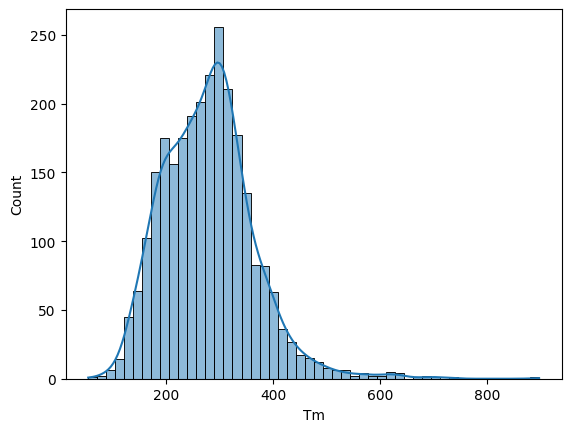

In [ ]:
sns.histplot(df['Tm'] , bins = 50, kde = True)

<Axes: xlabel='Tm', ylabel='Count'>

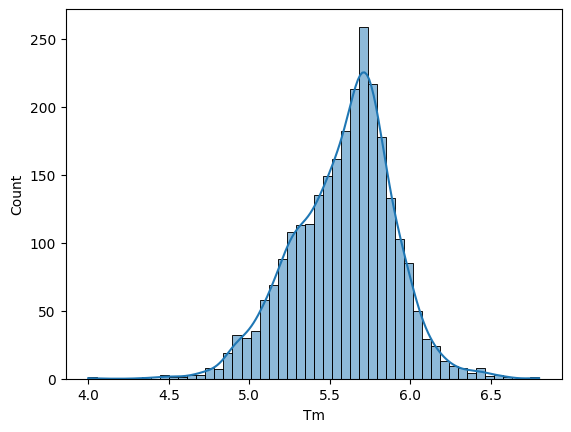

In [ ]:
sns.histplot(np.log1p(df['Tm']), bins=50, kde=True)

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 10.9 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

##Molecule Object

smile_eg = df['SMILES'].iloc[0]
mol = Chem.MolFromSmiles(smile_eg)

In [ ]:
for atom in mol.GetAtoms():
  print(atom.GetSymbol(), atom.GetAtomicNum())

F 9
C 6
C 6
F 9
C 6
F 9
F 9
C 6
F 9
F 9


In [ ]:
for bond in mol.GetBonds():
  print(bond.GetBondType())

SINGLE
DOUBLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE
SINGLE


In [ ]:
from rdkit.Chem import Descriptors

desc_names = [desc[0] for desc in Descriptors._descList]

def rdkit_descriptors(smiles):
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
    return None
  return [desc[1](mol) for desc in Descriptors._descList]

desc_df = df['SMILES'].apply(rdkit_descriptors)
desc_df = pd.DataFrame(desc_df.tolist(), columns = desc_names)

desc_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,161.990419,58,...,0,0,0,0,0,0,0,0,0,0
1,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,217.089149,80,...,0,0,0,0,0,0,0,0,0,0
2,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,160.100048,62,...,0,0,0,0,0,0,0,0,0,0
3,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,84.021129,32,...,0,0,0,0,0,0,0,0,0,0
4,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,118.081621,44,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
target = df['Tm']

In [ ]:
mi_df = pd.concat([desc_df, target], axis = 1)
mi_df.shape

(2662, 218)

##Selection of Optimal Features

####Variance Threshold

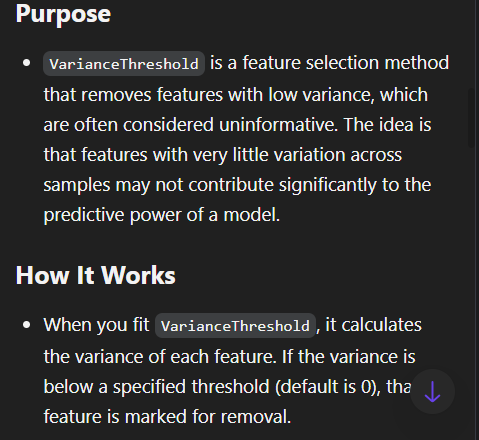

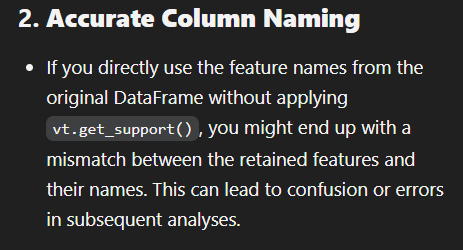

In [ ]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold = 0.0)
df_vt = pd.DataFrame(vt.fit_transform(desc_df), columns = desc_df.columns[vt.get_support()])

####Mutual Info Score

In [ ]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(df_vt ,target , random_state = 11)
mi_scores = pd.Series(mi, index = df_vt.columns).sort_values(ascending = False)
mi_scores

,0
BertzCT,0.284215
HeavyAtomMolWt,0.268596
HallKierAlpha,0.260611
Chi1,0.253669
LabuteASA,0.237087
...,...
fr_phos_ester,0.000000
fr_thiazole,0.000000
fr_sulfone,0.000000
fr_sulfonamd,0.000000


In [ ]:
decent_features = mi_scores[mi_scores > 0.01]
decent_features

,0
BertzCT,0.284215
HeavyAtomMolWt,0.268596
HallKierAlpha,0.260611
Chi1,0.253669
LabuteASA,0.237087
...,...
fr_amide,0.010670
NumSaturatedCarbocycles,0.010452
fr_lactone,0.010426
fr_nitro,0.010340


In [ ]:
dec_feature_names = decent_features.index
dec_fea_df = df_vt[dec_feature_names]
dec_fea_df

,BertzCT,HeavyAtomMolWt,HallKierAlpha,Chi1,LabuteASA,MolMR,Chi0,NumValenceElectrons,NumAromaticRings,AvgIpc,...,fr_nitro_arom_nonortho,NumHeterocycles,PEOE_VSA5,fr_halogen,NumAtomStereoCenters,fr_amide,NumSaturatedCarbocycles,fr_lactone,fr_nitro,NumAmideBonds
0,179.793356,162.032,-0.68,4.315384,51.131856,19.1360,8.154701,58.0,0.0,1.839682,...,0.0,0.0,0.00000,6.0,0.0,0.0,0.0,0.0,0.0,0.0
1,833.661406,206.183,-2.28,8.432653,98.685557,73.3107,11.242276,80.0,4.0,2.772076,...,0.0,1.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,401.130826,148.124,-1.31,5.825699,71.846674,50.1440,8.552042,62.0,2.0,2.396359,...,0.0,1.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,104.451830,80.042,-0.97,2.770056,35.789059,21.0858,4.991564,32.0,0.0,1.348588,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,33.161259,104.133,0.35,3.270056,51.719028,37.9730,5.698671,44.0,0.0,1.612197,...,0.0,0.0,0.00000,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,8.000000,139.379,0.77,1.914214,39.275007,24.5140,3.414214,26.0,0.0,1.370951,...,0.0,0.0,11.60094,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2658,75.774438,144.388,0.36,2.560660,50.406572,25.9030,5.207107,34.0,0.0,1.351644,...,0.0,0.0,0.00000,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2659,413.307866,144.132,-1.30,5.770857,72.842952,53.4220,8.552042,60.0,2.0,2.039179,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2660,471.374187,172.142,-1.63,6.808862,83.369416,58.5695,9.966255,70.0,2.0,2.271175,...,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


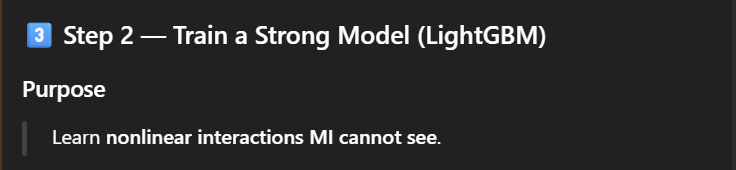

In [ ]:
!pip install lightgbm

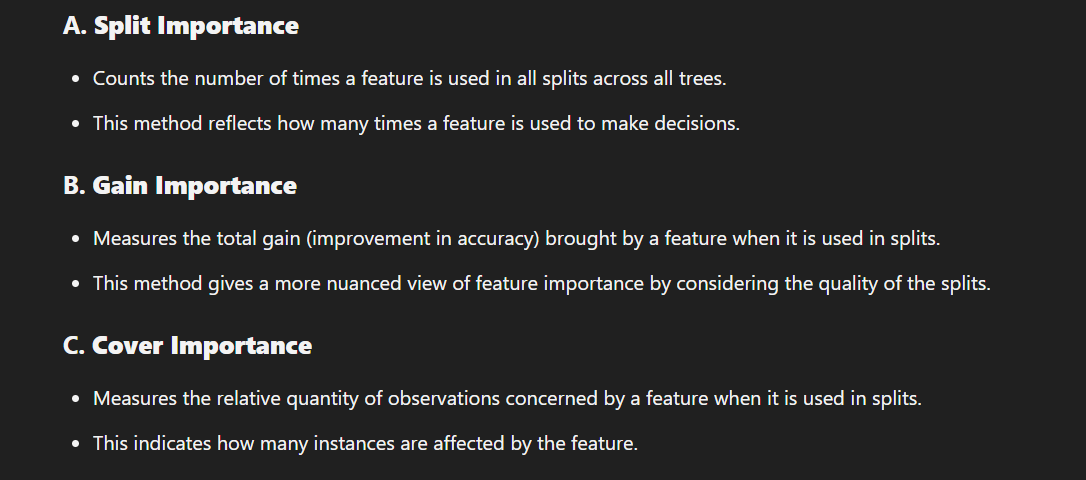

In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(n_estimators = 2000, learning_rate = 0.03,random_state = 11)
lgbm.fit(dec_fea_df,target)

importance_gain = lgbm.booster_.feature_importance(importance_type = 'gain')
importance_split = lgbm.booster_.feature_importance(importance_type = 'split')

feature_names = lgbm.booster_.feature_name()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18746
[LightGBM] [Info] Number of data points in the train set: 2662, number of used features: 150
[LightGBM] [Info] Start training from score 278.263449


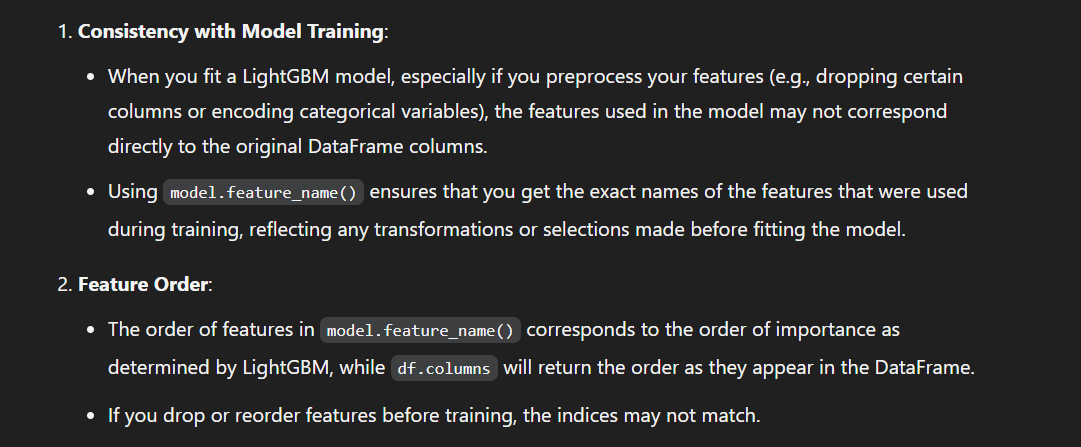

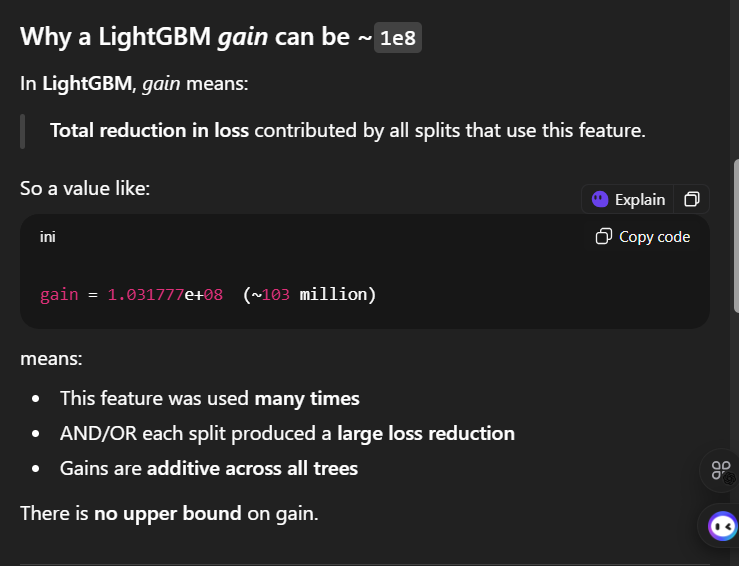

#####Split Importance

####Importances Combined

In [ ]:
gain_importance = lgbm.booster_.feature_importance(importance_type = 'gain')
split_importance = lgbm.booster_.feature_importance(importance_type = 'split')

feature_names = lgbm.booster_.feature_name()

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'Gain': gain_importance,
    'Split': split_importance
})

df_imp.head()

,Feature,Gain,Split
0,BertzCT,1.031777e+08,1955
1,HeavyAtomMolWt,2.379617e+06,569
2,HallKierAlpha,1.710747e+06,340
3,Chi1,7.044609e+05,447
4,LabuteASA,2.465018e+06,578


In [ ]:
df_imp["gain_pct"]  = df_imp["Gain"]  / df_imp["Gain"].sum()
df_imp["split_pct"] = df_imp["Split"] / df_imp["Split"].sum()

drop_features = df_imp[
    (df_imp["gain_pct"]  < 0.001) &
    (df_imp["split_pct"] < 0.001)
]["Feature"]


In [ ]:
drop_features

,Feature
8,NumAromaticRings
14,NumAromaticCarbocycles
17,fr_benzene
68,MaxEStateIndex
78,SlogP_VSA10
83,SMR_VSA9
85,NumHAcceptors
87,EState_VSA10
96,fr_phenol
97,fr_aniline


In [ ]:
dec_fea_df.head()

,BertzCT,HeavyAtomMolWt,HallKierAlpha,Chi1,LabuteASA,MolMR,Chi0,NumValenceElectrons,NumAromaticRings,AvgIpc,...,fr_nitro_arom_nonortho,NumHeterocycles,PEOE_VSA5,fr_halogen,NumAtomStereoCenters,fr_amide,NumSaturatedCarbocycles,fr_lactone,fr_nitro,NumAmideBonds
0,179.793356,162.032,-0.68,4.315384,51.131856,19.1360,8.154701,58.0,0.0,1.839682,...,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
1,833.661406,206.183,-2.28,8.432653,98.685557,73.3107,11.242276,80.0,4.0,2.772076,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,401.130826,148.124,-1.31,5.825699,71.846674,50.1440,8.552042,62.0,2.0,2.396359,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,104.451830,80.042,-0.97,2.770056,35.789059,21.0858,4.991564,32.0,0.0,1.348588,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,33.161259,104.133,0.35,3.270056,51.719028,37.9730,5.698671,44.0,0.0,1.612197,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


####Pre Pruning CV

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

X = dec_fea_df
y = target

N_SPLITS = 5
SEEDS = [42, 101, 777]

all_seed_scores = []

for seed in SEEDS:
    print(f"\nRunning CV for seed = {seed}")

    kf = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed
    )

    oof = np.zeros(len(y))
    fold_scores = []

    for fold, (tr, val) in enumerate(kf.split(X), 1):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]

        model = lgb.LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=64,
            random_state=seed,   # ✅ single int
        )

        early_stopping = lgb.early_stopping(
            stopping_rounds=100,
            verbose=False
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="mae",
            callbacks=[early_stopping]
        )

        preds = model.predict(X_val)
        oof[val] = preds

        fold_scores.append(mean_absolute_error(y_val, preds))

    seed_cv = np.mean(fold_scores)
    all_seed_scores.append(seed_cv)

    print(f"Seed {seed} CV MAE: {seed_cv}")

print("\n==============================")
print("Final Multi-seed CV MAE:", np.mean(all_seed_scores))
print("Std across seeds:", np.std(all_seed_scores))



Running CV for seed = 42
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006340 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18192
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 149
[LightGBM] [Info] Start training from score 277.791617
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18188
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 150
[LightGBM] [Info] Start training from score 278.890621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003799 seconds.
You can set `force_row_wise=true` to remove the over

In [ ]:
dec_fea_ff = dec_fea_df.drop(columns = drop_features)
dec_fea_ff.head()

,BertzCT,HeavyAtomMolWt,HallKierAlpha,Chi1,LabuteASA,MolMR,Chi0,NumValenceElectrons,AvgIpc,SMR_VSA7,...,PEOE_VSA11,PEOE_VSA14,SlogP_VSA12,EState_VSA1,fr_COO,NumBridgeheadAtoms,PEOE_VSA3,NumHeterocycles,PEOE_VSA5,fr_amide
0,179.793356,162.032,-0.68,4.315384,51.131856,19.1360,8.154701,58.0,1.839682,11.653748,...,0.0,11.845058,0.000000,23.498806,0.0,0.0,8.780830,0.0,0.0,0.0
1,833.661406,206.183,-2.28,8.432653,98.685557,73.3107,11.242276,80.0,2.772076,60.663671,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.0,0.0,0.0
2,401.130826,148.124,-1.31,5.825699,71.846674,50.1440,8.552042,62.0,2.396359,30.089873,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,4.983979,1.0,0.0,0.0
3,104.451830,80.042,-0.97,2.770056,35.789059,21.0858,4.991564,32.0,1.348588,0.000000,...,0.0,5.969305,0.000000,5.969305,1.0,0.0,4.794537,0.0,0.0,0.0
4,33.161259,104.133,0.35,3.270056,51.719028,37.9730,5.698671,44.0,1.612197,0.000000,...,0.0,0.000000,12.628789,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

X = dec_fea_ff
y = target

N_SPLITS = 5
SEEDS = [42, 101, 777]

all_seed_scores = []

for seed in SEEDS:
    print(f"\nRunning CV for seed = {seed}")

    kf = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed
    )

    oof = np.zeros(len(y))
    fold_scores = []

    for fold, (tr, val) in enumerate(kf.split(X), 1):
        X_tr, X_val = X.iloc[tr], X.iloc[val]
        y_tr, y_val = y.iloc[tr], y.iloc[val]

        model = lgb.LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=64,
            random_state=seed,   # ✅ single int
        )

        early_stopping = lgb.early_stopping(
            stopping_rounds=100,
            verbose=False
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="mae",
            callbacks=[early_stopping]
        )

        preds = model.predict(X_val)
        oof[val] = preds

        fold_scores.append(mean_absolute_error(y_val, preds))

    seed_cv = np.mean(fold_scores)
    all_seed_scores.append(seed_cv)

    print(f"Seed {seed} CV MAE: {seed_cv}")

print("\n==============================")
print("Final Multi-seed CV MAE:", np.mean(all_seed_scores))
print("Std across seeds:", np.std(all_seed_scores))



Running CV for seed = 42
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17667
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 110
[LightGBM] [Info] Start training from score 277.791617
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001973 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17666
[LightGBM] [Info] Number of data points in the train set: 2129, number of used features: 110
[LightGBM] [Info] Start training from score 278.890621
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004180 seconds.
You can set `force_col_wise=true` to remove the over

In [ ]:
# !pip install optuna

In [ ]:
# # =========================
# # FAST PIPELINE: LightGBM + Multi-Seed CV + Optuna (MAE)
# # =========================

# import numpy as np
# import optuna
# import lightgbm as lgb

# from sklearn.model_selection import KFold
# from sklearn.metrics import mean_absolute_error

# # -------------------------
# # Data
# # -------------------------
# X = dec_fea_ff.copy()
# y = target.copy()

# SEEDS = [42, 101, 777]

# # -------------------------
# # FAST CV runner
# # -------------------------
# def run_cv(X, y, params, n_splits):
#     seed_scores = []

#     for seed in SEEDS:
#         kf = KFold(
#             n_splits=n_splits,
#             shuffle=True,
#             random_state=seed
#         )

#         fold_scores = []

#         for tr, val in kf.split(X):
#             X_tr, X_val = X.iloc[tr], X.iloc[val]
#             y_tr, y_val = y.iloc[tr], y.iloc[val]

#             model = lgb.LGBMRegressor(
#                 **params,
#                 n_estimators=3000,          # ⬅ reduced
#                 random_state=seed,
#                 force_col_wise=True         # ⬅ big speedup
#             )

#             model.fit(
#                 X_tr, y_tr,
#                 eval_set=[(X_val, y_val)],
#                 eval_metric="mae",
#                 callbacks=[lgb.early_stopping(100, verbose=False)]
#             )

#             preds = model.predict(X_val)
#             fold_scores.append(mean_absolute_error(y_val, preds))

#         seed_scores.append(np.mean(fold_scores))

#     return np.mean(seed_scores)

# # -------------------------
# # Baseline (FULL CV)
# # -------------------------
# baseline_params = {
#     "learning_rate": 0.03,
#     "num_leaves": 64,
#     "max_depth": -1,
#     "min_child_samples": 20,
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "reg_alpha": 0.0,
#     "reg_lambda": 0.0,
#     "objective": "regression",
#     "metric": "mae",
#     "verbosity": -1
# }

# baseline_cv = run_cv(X, y, baseline_params, n_splits=5)
# print(f"Baseline CV MAE: {baseline_cv:.5f}")

# # -------------------------
# # Optuna objective (FAST CV)
# # -------------------------
# def objective(trial):

#     params = {
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
#         "num_leaves": trial.suggest_int("num_leaves", 16, 256),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "min_child_samples": trial.suggest_int("min_child_samples", 10, 300),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
#         "objective": "regression",
#         "metric": "mae",
#         "verbosity": -1
#     }

#     return run_cv(X, y, params, n_splits=3)  # ⬅ fewer folds

# # -------------------------
# # Run Optuna (FASTER)
# # -------------------------
# study = optuna.create_study(
#     direction="minimize",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
# )

# study.optimize(objective, n_trials=30)  # ⬅ fewer trials

# print("\nBest CV MAE:", study.best_value)
# print("Best Params:", study.best_params)

# # -------------------------
# # Final FULL training
# # -------------------------
# best_params = study.best_params
# final_models = []

# for seed in SEEDS:
#     model = lgb.LGBMRegressor(
#         **best_params,
#         n_estimators=3000,
#         random_state=seed,
#         force_col_wise=True
#     )
#     model.fit(X, y)
#     final_models.append(model)

# # final_preds = np.mean([m.predict(X_test) for m in final_models], axis=0)


image.png

image.png

###Baseline CV MAE > Optuna CV MAE

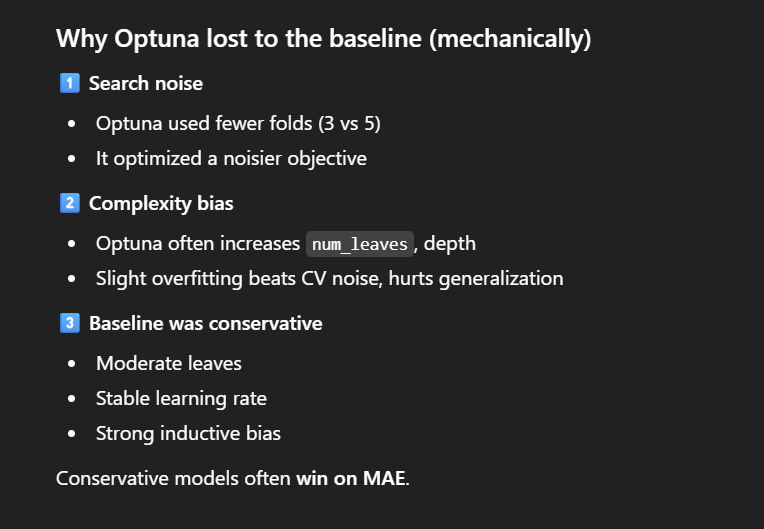

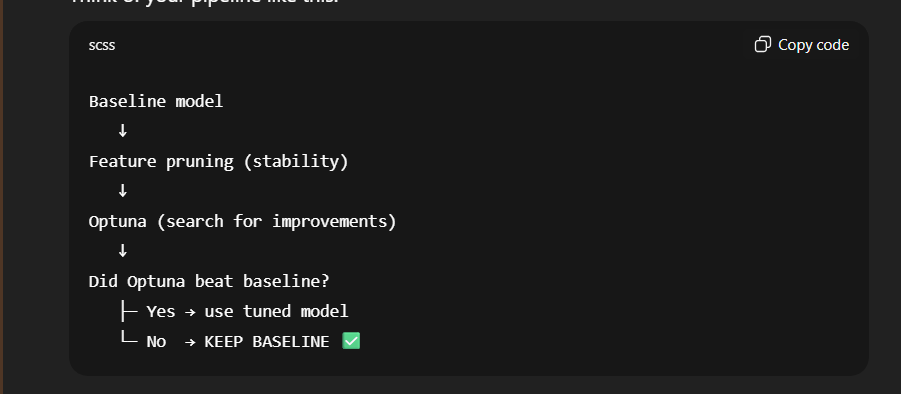

###SHAP Analysis

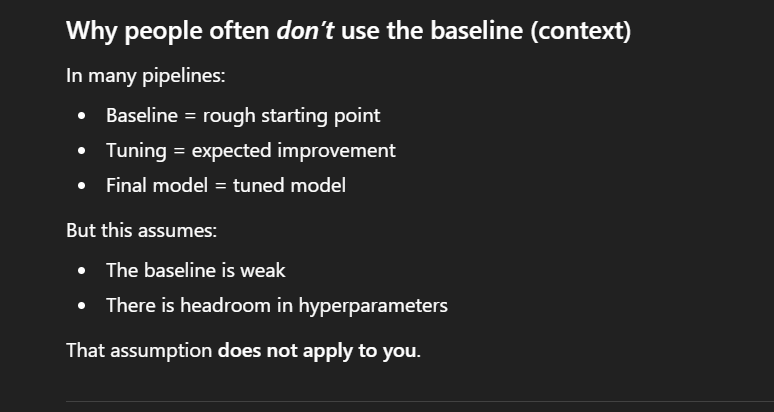

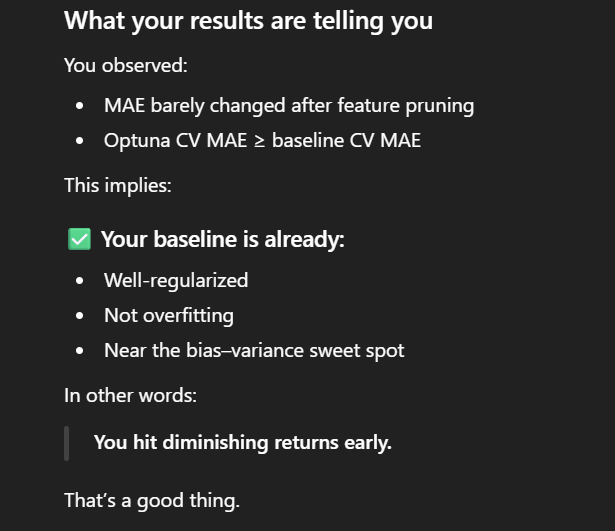

In [ ]:
X.head()

,BertzCT,HeavyAtomMolWt,HallKierAlpha,Chi1,LabuteASA,MolMR,Chi0,NumValenceElectrons,AvgIpc,SMR_VSA7,...,PEOE_VSA11,PEOE_VSA14,SlogP_VSA12,EState_VSA1,fr_COO,NumBridgeheadAtoms,PEOE_VSA3,NumHeterocycles,PEOE_VSA5,fr_amide
0,179.793356,162.032,-0.68,4.315384,51.131856,19.1360,8.154701,58.0,1.839682,11.653748,...,0.0,11.845058,0.000000,23.498806,0.0,0.0,8.780830,0.0,0.0,0.0
1,833.661406,206.183,-2.28,8.432653,98.685557,73.3107,11.242276,80.0,2.772076,60.663671,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.0,0.0,0.0
2,401.130826,148.124,-1.31,5.825699,71.846674,50.1440,8.552042,62.0,2.396359,30.089873,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,4.983979,1.0,0.0,0.0
3,104.451830,80.042,-0.97,2.770056,35.789059,21.0858,4.991564,32.0,1.348588,0.000000,...,0.0,5.969305,0.000000,5.969305,1.0,0.0,4.794537,0.0,0.0,0.0
4,33.161259,104.133,0.35,3.270056,51.719028,37.9730,5.698671,44.0,1.612197,0.000000,...,0.0,0.000000,12.628789,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


In [ ]:
from lightgbm import LGBMRegressor

baseline_params = {
    "learning_rate": 0.03,
    "num_leaves": 64,
    "max_depth": -1,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 0.0,
    "objective": "regression",
    "metric": "mae",
    "verbosity": -1
}

baseline_model = LGBMRegressor(
    **baseline_params,
    n_estimators = 3000,
    force_col_wise = True,
    random_state = 11
)

baseline_model.fit(X,y)


LGBMRegressor(colsample_bytree=0.8, force_col_wise=True, learning_rate=0.03,
              metric='mae', n_estimators=3000, num_leaves=64,
              objective='regression', random_state=11, subsample=0.8,
              verbosity=-1)

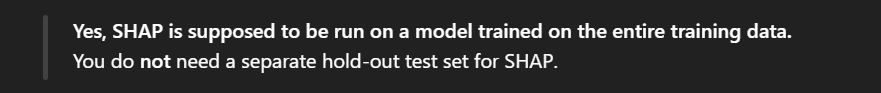

In [ ]:
!pip install shap
from shap import TreeExplainer

explainer = TreeExplainer(baseline_model)
shap_values = explainer.shap_values(X)

NameError: name 'shap' is not defined

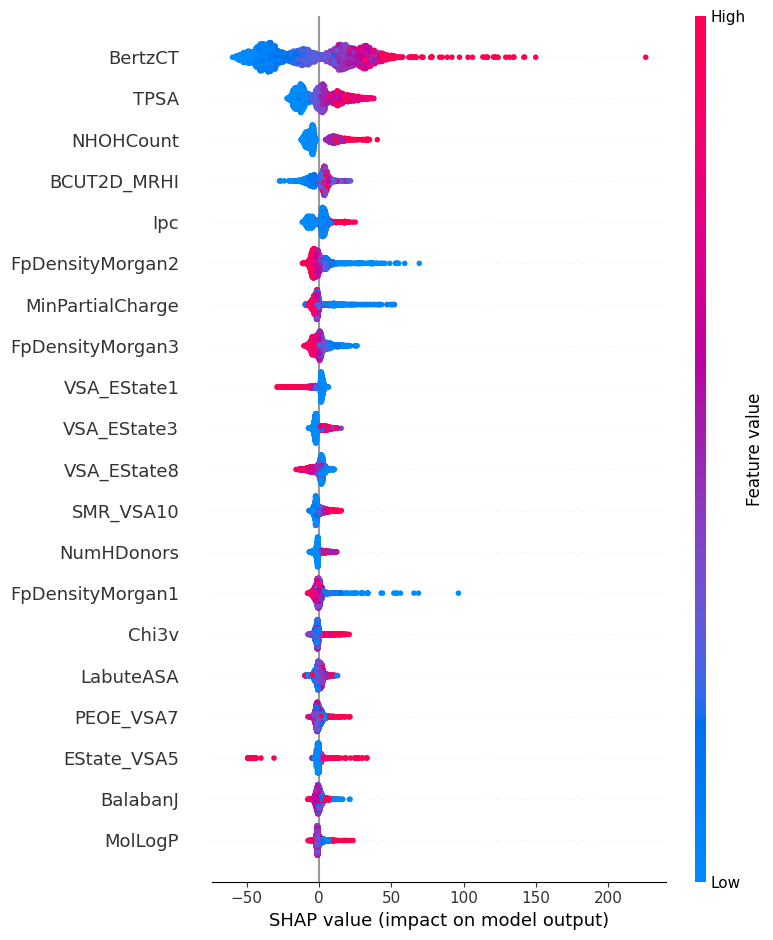

In [ ]:
import shap
shap.summary_plot(shap_values, X, plot_type="dot")

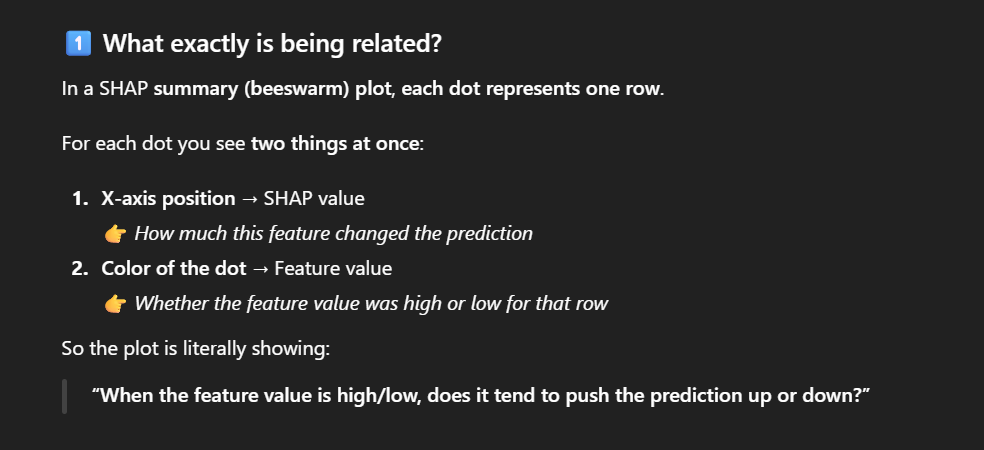

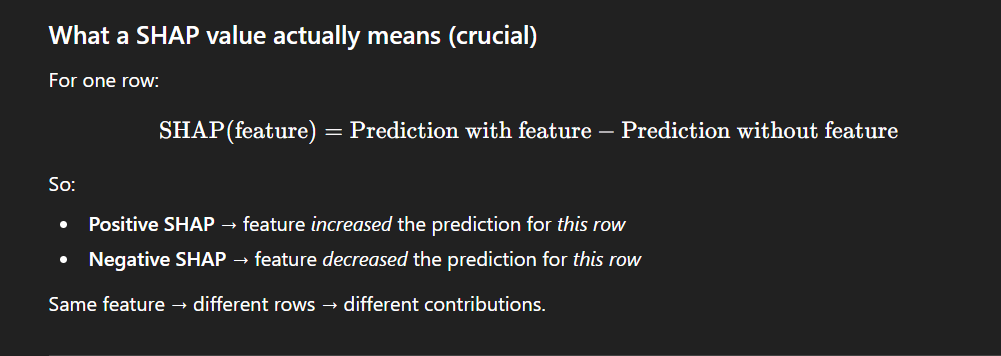

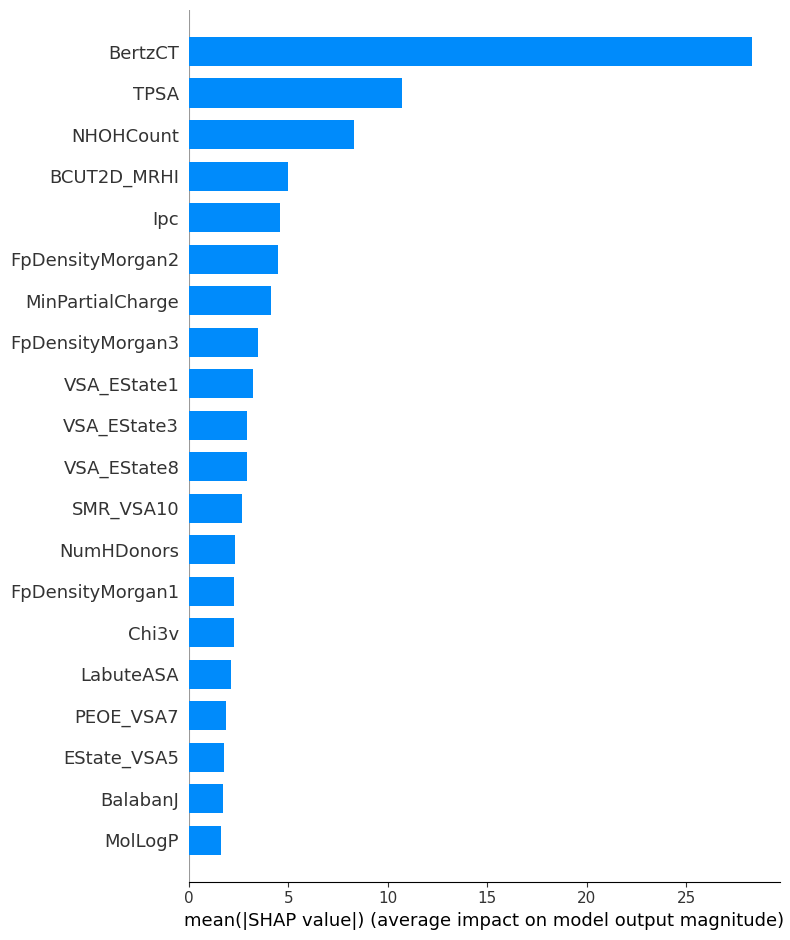

In [ ]:
shap.summary_plot(shap_values, X, plot_type = "bar")

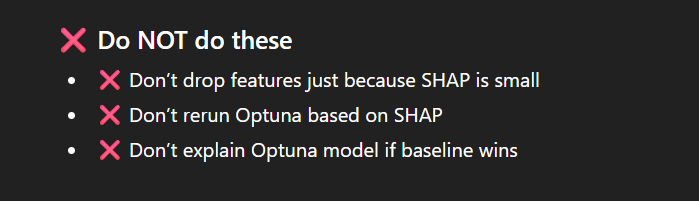

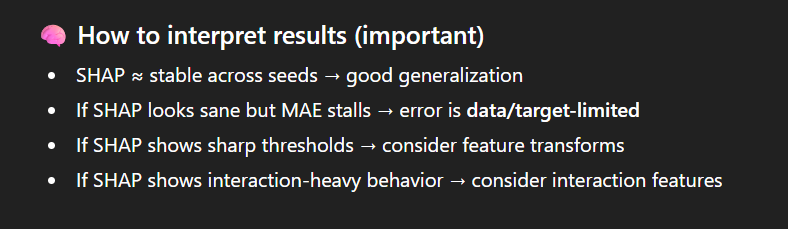

###Final RDKIT Features

In [ ]:
X.head()

,BertzCT,HeavyAtomMolWt,HallKierAlpha,Chi1,LabuteASA,MolMR,Chi0,NumValenceElectrons,AvgIpc,SMR_VSA7,...,PEOE_VSA11,PEOE_VSA14,SlogP_VSA12,EState_VSA1,fr_COO,NumBridgeheadAtoms,PEOE_VSA3,NumHeterocycles,PEOE_VSA5,fr_amide
0,179.793356,162.032,-0.68,4.315384,51.131856,19.1360,8.154701,58.0,1.839682,11.653748,...,0.0,11.845058,0.000000,23.498806,0.0,0.0,8.780830,0.0,0.0,0.0
1,833.661406,206.183,-2.28,8.432653,98.685557,73.3107,11.242276,80.0,2.772076,60.663671,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1.0,0.0,0.0
2,401.130826,148.124,-1.31,5.825699,71.846674,50.1440,8.552042,62.0,2.396359,30.089873,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,4.983979,1.0,0.0,0.0
3,104.451830,80.042,-0.97,2.770056,35.789059,21.0858,4.991564,32.0,1.348588,0.000000,...,0.0,5.969305,0.000000,5.969305,1.0,0.0,4.794537,0.0,0.0,0.0
4,33.161259,104.133,0.35,3.270056,51.719028,37.9730,5.698671,44.0,1.612197,0.000000,...,0.0,0.000000,12.628789,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


In [ ]:
x_dense = X.copy()

###Onwards to Descriptor/Fingerprint Features, Highly Sparse

In [ ]:
df2 = pd.read_csv("/content/train.csv")
df2.head()

,id,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
x_sparse = df2.drop(columns = ['id','SMILES','Tm']).copy()

In [ ]:
x_sparse.head()

,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,Group 9,Group 10,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


###BaseLine CV prior to Pruning

In [ ]:
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# ------------------------
# Parameters
# ------------------------
params = {
    "learning_rate": 0.03,
    "num_leaves": 48,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "objective": "regression",
    "metric": "mae",
    "verbosity": -1,
    "random_state": 11,
    "n_estimators": 3000
}


N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=11)

oof_preds = np.zeros(len(target))
fold_scores = []


for fold, (tr_idx, val_idx) in enumerate(kf.split(x_sparse), 1):
    print(f"\n===== Fold {fold} =====")

    X_tr, X_val = x_sparse.iloc[tr_idx], x_sparse.iloc[val_idx]
    y_tr, y_val = target.iloc[tr_idx], target.iloc[val_idx]

    model = LGBMRegressor(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(200)
        ]
    )

    preds = model.predict(X_val)
    oof_preds[val_idx] = preds

    fold_mae = mean_absolute_error(y_val, preds)
    fold_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.5f}")

# ------------------------
# CV results
# ------------------------
print("\n========================")
print(f"CV MAE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")



===== Fold 1 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 48.3884
[400]	valid_0's l1: 48.0053
[600]	valid_0's l1: 47.7784
[800]	valid_0's l1: 47.5972
[1000]	valid_0's l1: 47.6207
Early stopping, best iteration is:
[897]	valid_0's l1: 47.5229
Fold 1 MAE: 47.52290

===== Fold 2 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 46.4257
[400]	valid_0's l1: 45.2145
[600]	valid_0's l1: 44.3588
[800]	valid_0's l1: 43.857
[1000]	valid_0's l1: 43.5807
[1200]	valid_0's l1: 43.328
[1400]	valid_0's l1: 43.0782
[1600]	valid_0's l1: 42.8057
[1800]	valid_0's l1: 42.6455
[2000]	valid_0's l1: 42.4868
[2200]	valid_0's l1: 42.3751
[2400]	valid_0's l1: 42.334
[2600]	valid_0's l1: 42.2169
[2800]	valid_0's l1: 42.1826
[3000]	valid_0's l1: 42.1632
Did not meet early stopping. Best iteration is:
[2982]	valid_0's l1: 42.1517
Fold 2 MAE: 42.15167

===== Fold 3 =====
Training until validation scores don't improve for 200 rounds
[20

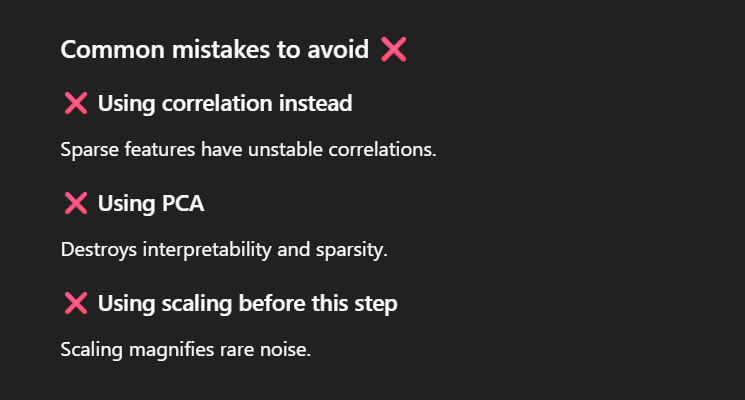

####Drop Zero Variance Feature

In [ ]:
from sklearn.feature_selection import VarianceThreshold

vt2 = VarianceThreshold(threshold = 0.0)

x_sparse_clean = pd.DataFrame(vt2.fit_transform(x_sparse), columns = x_sparse.columns[vt2.get_support()])

x_sparse_clean.head()

,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,Group 9,Group 10,...,Group 406,Group 407,Group 408,Group 409,Group 410,Group 412,Group 414,Group 415,Group 416,Group 418
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# ------------------------
# Parameters
# ------------------------
params = {
    "learning_rate": 0.03,
    "num_leaves": 48,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "objective": "regression",
    "metric": "mae",
    "verbosity": -1,
    "random_state": 11,
    "n_estimators": 3000
}


N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=11)

oof_preds = np.zeros(len(target))
fold_scores = []


for fold, (tr_idx, val_idx) in enumerate(kf.split(x_sparse_clean), 1):
    print(f"\n===== Fold {fold} =====")

    X_tr, X_val = x_sparse_clean.iloc[tr_idx], x_sparse_clean.iloc[val_idx]
    y_tr, y_val = target.iloc[tr_idx], target.iloc[val_idx]

    model = LGBMRegressor(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(200)
        ]
    )

    preds = model.predict(X_val)
    oof_preds[val_idx] = preds

    fold_mae = mean_absolute_error(y_val, preds)
    fold_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.5f}")

# ------------------------
# CV results
# ------------------------
print("\n========================")
print(f"CV MAE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")



===== Fold 1 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 48.3884
[400]	valid_0's l1: 48.0053
[600]	valid_0's l1: 47.7784
[800]	valid_0's l1: 47.5972
[1000]	valid_0's l1: 47.6207
Early stopping, best iteration is:
[897]	valid_0's l1: 47.5229
Fold 1 MAE: 47.52290

===== Fold 2 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 46.4257
[400]	valid_0's l1: 45.2145
[600]	valid_0's l1: 44.3588
[800]	valid_0's l1: 43.857
[1000]	valid_0's l1: 43.5807
[1200]	valid_0's l1: 43.328
[1400]	valid_0's l1: 43.0782
[1600]	valid_0's l1: 42.8057
[1800]	valid_0's l1: 42.6455
[2000]	valid_0's l1: 42.4868
[2200]	valid_0's l1: 42.3751
[2400]	valid_0's l1: 42.334
[2600]	valid_0's l1: 42.2169
[2800]	valid_0's l1: 42.1826
[3000]	valid_0's l1: 42.1632
Did not meet early stopping. Best iteration is:
[2982]	valid_0's l1: 42.1517
Fold 2 MAE: 42.15167

===== Fold 3 =====
Training until validation scores don't improve for 200 rounds
[20

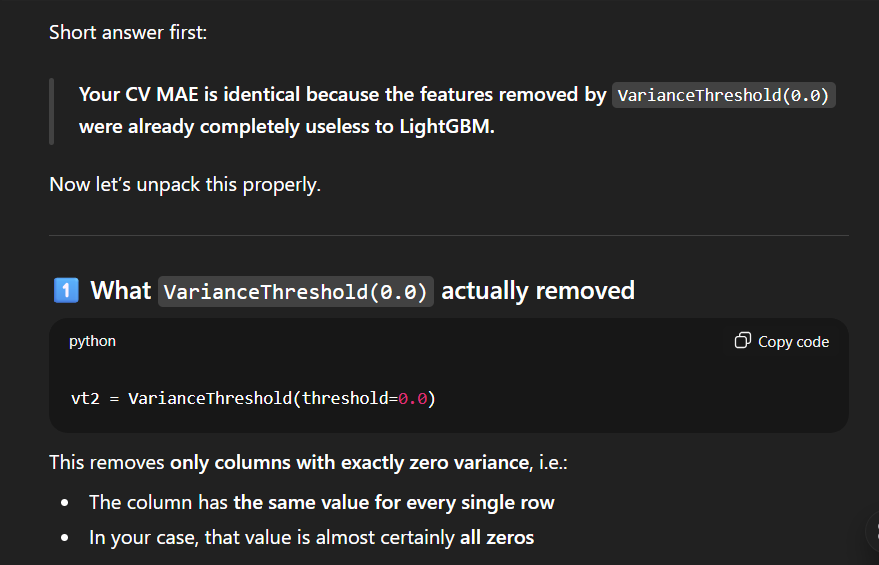

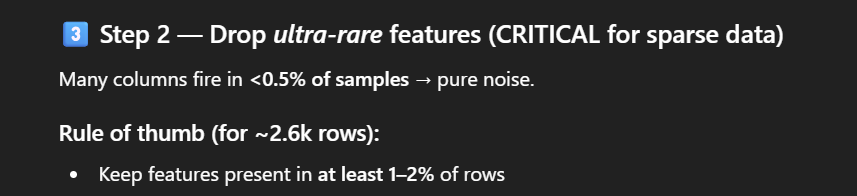

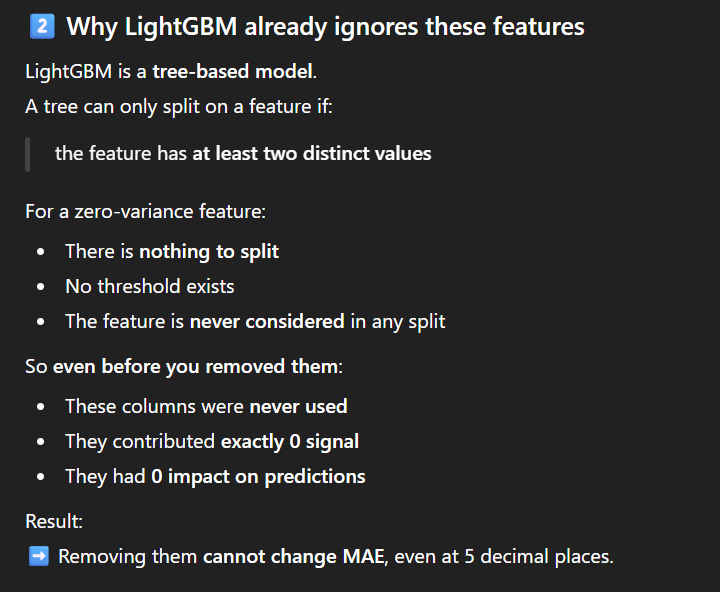

In [ ]:
non_zero_frac = (x_sparse_clean != 0).mean().sort_values(ascending = False)
non_zero_frac

,0
Group 1,0.530053
Group 15,0.462059
Group 2,0.346732
Group 20,0.122089
Group 168,0.095417
...,...
Group 380,0.000376
Group 387,0.000376
Group 386,0.000376
Group 381,0.000376


In [ ]:
type(non_zero_frac)

pandas.core.series.Series

In [ ]:
x_sparse_clean = x_sparse_clean.loc[:, non_zero_frac >= 0.01]  #keep features which have atleast 1 percent non zero values
x_sparse_clean.head()

,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 13,Group 15,Group 16,...,Group 327,Group 328,Group 331,Group 365,Group 367,Group 372,Group 374,Group 401,Group 402,Group 403
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,10,2,...,0,0,0,1,0,0,0,2,0,0
2,2,1,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# ------------------------
# Parameters
# ------------------------
params = {
    "learning_rate": 0.03,
    "num_leaves": 48,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "objective": "regression",
    "metric": "mae",
    "verbosity": -1,
    "random_state": 11,
    "n_estimators": 3000
}


N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=11)

oof_preds = np.zeros(len(target))
fold_scores = []


for fold, (tr_idx, val_idx) in enumerate(kf.split(x_sparse_clean), 1):
    print(f"\n===== Fold {fold} =====")

    X_tr, X_val = x_sparse_clean.iloc[tr_idx], x_sparse_clean.iloc[val_idx]
    y_tr, y_val = target.iloc[tr_idx], target.iloc[val_idx]

    model = LGBMRegressor(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(200)
        ]
    )

    preds = model.predict(X_val)
    oof_preds[val_idx] = preds

    fold_mae = mean_absolute_error(y_val, preds)
    fold_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.5f}")

# ------------------------
# CV results
# ------------------------
print("\n========================")
print(f"CV MAE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")



===== Fold 1 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 48.3884
[400]	valid_0's l1: 48.0053
[600]	valid_0's l1: 47.7784
[800]	valid_0's l1: 47.5972
[1000]	valid_0's l1: 47.6207
Early stopping, best iteration is:
[897]	valid_0's l1: 47.5229
Fold 1 MAE: 47.52290

===== Fold 2 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 46.4257
[400]	valid_0's l1: 45.2145
[600]	valid_0's l1: 44.3588
[800]	valid_0's l1: 43.857
[1000]	valid_0's l1: 43.5807
[1200]	valid_0's l1: 43.328
[1400]	valid_0's l1: 43.0782
[1600]	valid_0's l1: 42.8057
[1800]	valid_0's l1: 42.6455
[2000]	valid_0's l1: 42.4868
[2200]	valid_0's l1: 42.3751
[2400]	valid_0's l1: 42.334
[2600]	valid_0's l1: 42.2169
[2800]	valid_0's l1: 42.1826
[3000]	valid_0's l1: 42.1632
Did not meet early stopping. Best iteration is:
[2982]	valid_0's l1: 42.1517
Fold 2 MAE: 42.15167

===== Fold 3 =====
Training until validation scores don't improve for 200 rounds
[20

In [ ]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(
    X=x_sparse_clean,
    y=target,
    discrete_features=False,
    n_neighbors=5,
    random_state=11
)

mi_series = pd.Series(
    mi_scores,
    index=x_sparse_clean.columns
).sort_values(ascending=False)

mi_series.head(20)


,0
Group 15,0.192702
Group 2,0.132647
Group 1,0.054647
Group 30,0.043866
Group 18,0.037783
Group 123,0.037304
Group 401,0.032547
Group 20,0.031888
Group 328,0.030168
Group 16,0.023757


In [ ]:
mi_series = mi_series[mi_series > 0]
x_mi = x_sparse_clean[mi_series.index]
x_mi.head()

,Group 15,Group 2,Group 1,Group 30,Group 18,Group 123,Group 401,Group 20,Group 328,Group 16,...,Group 22,Group 49,Group 296,Group 38,Group 319,Group 169,Group 327,Group 297,Group 181,Group 172
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,10,0,0,0,0,0,2,0,0,2,...,0,0,0,0,0,0,0,0,0,0
2,4,1,2,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,3,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# ------------------------
# Parameters
# ------------------------
params = {
    "learning_rate": 0.03,
    "num_leaves": 48,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "objective": "regression",
    "metric": "mae",
    "verbosity": -1,
    "random_state": 11,
    "n_estimators": 3000
}


N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=11)

oof_preds = np.zeros(len(target))
fold_scores = []


for fold, (tr_idx, val_idx) in enumerate(kf.split(x_mi), 1):
    print(f"\n===== Fold {fold} =====")

    X_tr, X_val = x_mi.iloc[tr_idx], x_mi.iloc[val_idx]
    y_tr, y_val = target.iloc[tr_idx], target.iloc[val_idx]

    model = LGBMRegressor(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(200)
        ]
    )

    preds = model.predict(X_val)
    oof_preds[val_idx] = preds

    fold_mae = mean_absolute_error(y_val, preds)
    fold_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.5f}")

# ------------------------
# CV results
# ------------------------
print("\n========================")
print(f"CV MAE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")



===== Fold 1 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 48.4336
[400]	valid_0's l1: 47.9863
[600]	valid_0's l1: 47.6466
[800]	valid_0's l1: 47.6295
[1000]	valid_0's l1: 47.6868
Early stopping, best iteration is:
[842]	valid_0's l1: 47.577
Fold 1 MAE: 47.57695

===== Fold 2 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 46.2678
[400]	valid_0's l1: 45.1834
[600]	valid_0's l1: 44.3628
[800]	valid_0's l1: 43.8417
[1000]	valid_0's l1: 43.3971
[1200]	valid_0's l1: 43.2628
[1400]	valid_0's l1: 43.0223
[1600]	valid_0's l1: 42.9291
[1800]	valid_0's l1: 42.7518
[2000]	valid_0's l1: 42.6116
[2200]	valid_0's l1: 42.4869
[2400]	valid_0's l1: 42.3675
[2600]	valid_0's l1: 42.2273
[2800]	valid_0's l1: 42.1622
[3000]	valid_0's l1: 42.1031
Did not meet early stopping. Best iteration is:
[2957]	valid_0's l1: 42.0976
Fold 2 MAE: 42.09759

===== Fold 3 =====
Training until validation scores don't improve for 200 rounds
[

In [ ]:
x_final = pd.concat([x_dense,x_mi], axis = 1)
x_final.head()

,BertzCT,HeavyAtomMolWt,HallKierAlpha,Chi1,LabuteASA,MolMR,Chi0,NumValenceElectrons,AvgIpc,SMR_VSA7,...,Group 22,Group 49,Group 296,Group 38,Group 319,Group 169,Group 327,Group 297,Group 181,Group 172
0,179.793356,162.032,-0.68,4.315384,51.131856,19.1360,8.154701,58.0,1.839682,11.653748,...,0,0,0,0,0,0,0,0,0,0
1,833.661406,206.183,-2.28,8.432653,98.685557,73.3107,11.242276,80.0,2.772076,60.663671,...,0,0,0,0,0,0,0,0,0,0
2,401.130826,148.124,-1.31,5.825699,71.846674,50.1440,8.552042,62.0,2.396359,30.089873,...,0,0,0,0,0,0,0,0,0,0
3,104.451830,80.042,-0.97,2.770056,35.789059,21.0858,4.991564,32.0,1.348588,0.000000,...,0,0,0,0,0,0,0,0,0,0
4,33.161259,104.133,0.35,3.270056,51.719028,37.9730,5.698671,44.0,1.612197,0.000000,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# ------------------------
# Parameters
# ------------------------
params = {
    "learning_rate": 0.03,
    "num_leaves": 48,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
    "objective": "regression",
    "metric": "mae",
    "verbosity": -1,
    "random_state": 11,
    "n_estimators": 3000
}


N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=11)

oof_preds = np.zeros(len(target))
fold_scores = []


for fold, (tr_idx, val_idx) in enumerate(kf.split(x_final), 1):
    print(f"\n===== Fold {fold} =====")

    X_tr, X_val = x_final.iloc[tr_idx], x_final.iloc[val_idx]
    y_tr, y_val = target.iloc[tr_idx], target.iloc[val_idx]

    model = LGBMRegressor(**params)

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[
            lgb.early_stopping(stopping_rounds=200),
            lgb.log_evaluation(200)
        ]
    )

    preds = model.predict(X_val)
    oof_preds[val_idx] = preds

    fold_mae = mean_absolute_error(y_val, preds)
    fold_scores.append(fold_mae)

    print(f"Fold {fold} MAE: {fold_mae:.5f}")

# ------------------------
# CV results
# ------------------------
print("\n========================")
print(f"CV MAE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")



===== Fold 1 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 32.4375
[400]	valid_0's l1: 31.9298
Early stopping, best iteration is:
[344]	valid_0's l1: 31.8624
Fold 1 MAE: 31.86235

===== Fold 2 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 29.0897
[400]	valid_0's l1: 28.2932
[600]	valid_0's l1: 28.1295
[800]	valid_0's l1: 28.1012
Early stopping, best iteration is:
[698]	valid_0's l1: 28.0754
Fold 2 MAE: 28.07540

===== Fold 3 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 29.3233
[400]	valid_0's l1: 28.6301
[600]	valid_0's l1: 28.5458
[800]	valid_0's l1: 28.4051
[1000]	valid_0's l1: 28.4296
Early stopping, best iteration is:
[809]	valid_0's l1: 28.392
Fold 3 MAE: 28.39196

===== Fold 4 =====
Training until validation scores don't improve for 200 rounds
[200]	valid_0's l1: 31.3908
[400]	valid_0's l1: 30.432
[600]	valid_0's l1: 30.223
[800]	valid_0's l1: 30.0459
[1